In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Inspect the data
trends.head()

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1


In [26]:
# Convert to date time & Set the index
trends['week'] = pd.to_datetime(trends['week'])
trends.set_index('week', inplace=True)

# Check to see if it worked
print(trends.head())
print(trends.index.dtype)

            chatgpt  gemini  microsoft_copilot
week                                          
2023-08-27       56       3                  1
2023-09-03       56       3                  1
2023-09-10       63       3                  1
2023-09-17       64       3                  1
2023-09-24       66       3                  1
datetime64[us]


In [27]:
# Calculate weekly percentage change for each tool
growth_rates = trends.pct_change().fillna(0).mul(100)

# Calculate standard deviation of growth rates for each tool
std_devs = growth_rates.std()

# Find the tool with the lowest standard deviation (most consistent growth)
most_consistent_tool = std_devs[std_devs == std_devs.min()].index[0]

print(std_devs)
print(f"Most consistent tool: {most_consistent_tool}")

chatgpt               8.966296
gemini               36.025774
microsoft_copilot    24.338599
dtype: float64
Most consistent tool: chatgpt


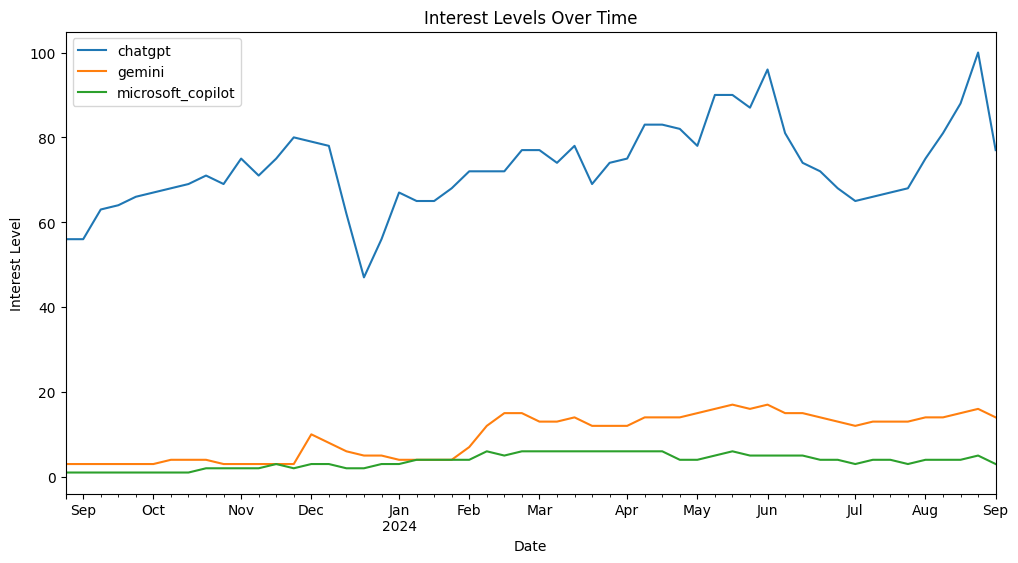

ChatGPT's largest dip: December 2023


In [28]:
# Copy the original dataframe to work with raw interest data
trends_copy = trends.copy()

# Plot interest levels for ChatGPT, Gemini, and Microsoft Copilot
trends_copy[['chatgpt', 'gemini', 'microsoft_copilot']].plot(
    title='Interest Levels Over Time',
    xlabel='Date',
    ylabel='Interest Level',
    figsize=(12, 6)
)

plt.show()

gpt_dip = "December 2023"
print(f"ChatGPT's largest dip: {gpt_dip}")

In [29]:
# Resample data into monthly averages ('M' threw a deprecated warning)
monthly_avg = trends.resample('ME').mean()

# Calculate the mean across all tools for each month, then sort descending
best_month = monthly_avg.mean(axis=1).sort_values(ascending=False).index[0].strftime('%B')

print(f"Month that had the highest average interest: {best_month}")

Month that had the highest average interest: May
